## Importation & Exploration

In [738]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("bank-transactions.csv")
print(f"Shape: {df.shape}")
display(df.info(), df.head())

Shape: (2060, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2060 entries, 0 to 2059
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       2060 non-null   object 
 1   client_id            2060 non-null   object 
 2   date_transaction     2060 non-null   object 
 3   montant              2060 non-null   object 
 4   devise               2060 non-null   object 
 5   taux_change_eur      2060 non-null   float64
 6   montant_eur          2060 non-null   float64
 7   categorie            2060 non-null   object 
 8   produit              2060 non-null   object 
 9   agence               1996 non-null   object 
 10  type_operation       2060 non-null   object 
 11  statut               2060 non-null   object 
 12  score_credit_client  1893 non-null   float64
 13  segment_client       1955 non-null   object 
 14  solde_avant          2060 non-null   object 
 15  taux_interet        

None

,transaction_id,client_id,date_transaction,montant,devise,taux_change_eur,montant_eur,categorie,produit,agence,type_operation,statut,score_credit_client,segment_client,solde_avant,taux_interet
0,TXN000559,CLI0060,2022-04-19 02:31:00,2050.42,EUR,1.00,2050.42,Depot especes,Compte Epargne,Marseille-Vieux-Port,Credit,Complete,NaN,Premium,16415.1,NaN
1,TXN001154,CLI0057,2024-06-20 20:51:00,-123.66,GBP,0.86,-143.79,Retrait DAB,Credit Consommation,NaN,Debit,Rejete,435.0,Risque,42890.81,NaN
2,TXN000764,CLI0015,2024-08-28 05:03:00,-396.17,EUR,1.00,-396.17,Prelevement,PEA,Lyon-Part-Dieu,Debit,Complete,648.0,Standard,48489.38,NaN
3,TXN001598,CLI0045,2024-01-07 08:16:00,225.2,EUR,1.00,225.20,Paiement CB,Credit Consommation,Bordeaux-Meriadeck,Credit,Complete,704.0,Standard,43962.51,NaN
4,TXN001873,CLI0034,2024-08-11 19:52:00,935.32,EUR,1.00,935.32,Interets,Credit Immobilier,Bordeaux-Meriadeck,Credit,Complete,457.0,Risque,17312.83,NaN


In [739]:
for col in df.columns:
    m_types = df[col].apply(type).unique()
    hidden_spaces = (df[col].astype(str).str.strip() == "").sum()
    if len(m_types) > 1 or hidden_spaces > 0:
        print(f"{col}: Mixed {m_types} | Empty spaces: {hidden_spaces}")

agence: Mixed [<class 'str'> <class 'float'>] | Empty spaces: 0
segment_client: Mixed [<class 'str'> <class 'float'>] | Empty spaces: 0


agence                   3.106796
score_credit_client      8.106796
segment_client           5.097087
taux_interet           100.000000
dtype: float64


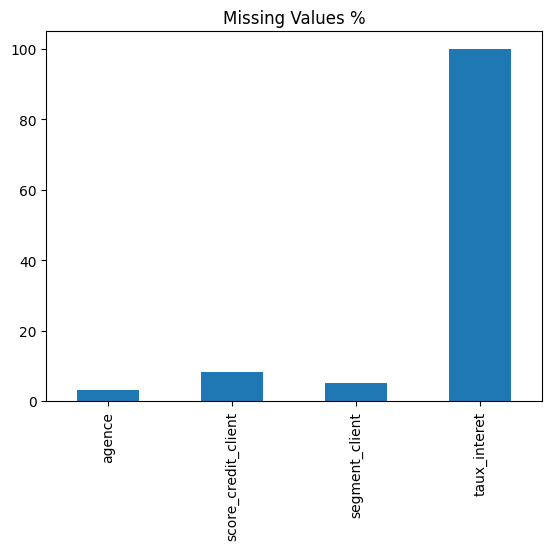

In [740]:
nan_pct = df.isnull().mean() * 100
print(nan_pct[nan_pct > 0])
nan_pct[nan_pct > 0].plot(kind='bar', title='Missing Values %')
plt.show()

In [741]:
df['tmp_date'] = pd.to_datetime(df['date_transaction'], errors='coerce')
dups = df[df.duplicated('transaction_id', keep=False)].sort_values(['transaction_id', 'tmp_date'])

print(f"Duplicate IDs: {dups['transaction_id'].nunique()}")
if not dups.empty:
    dups['gap'] = dups.groupby('transaction_id')['tmp_date'].diff()
    display(dups[['transaction_id', 'date_transaction', 'gap']].head())

df.drop(columns=['tmp_date'], inplace=True)

Duplicate IDs: 60


,transaction_id,date_transaction,gap
750,TXN000034,2024-02-21 18:22:00,NaT
1379,TXN000034,2024-02-21 18:22:03,0 days 00:00:03
394,TXN000052,2024-05-31 03:50:03,NaT
1128,TXN000052,31/05/2024 03:50,NaT
112,TXN000116,2024-11-09 17:31:00,NaT


## Nettoyage des données

In [742]:
doublons = df[df.duplicated(subset=['transaction_id'],keep=False)]
print(doublons.sort_values('transaction_id'))

     transaction_id client_id     date_transaction   montant devise  \
750       TXN000034   CLI0099  2024-02-21 18:22:00       0.0    EUR   
1379      TXN000034   CLI0099  2024-02-21 18:22:03    1745.7    EUR   
1128      TXN000052   CLI0076     31/05/2024 03:50   2120.25    EUR   
394       TXN000052   CLI0076  2024-05-31 03:50:03   2120.25    EUR   
14        TXN000116   CLI0077  2024-11-09 17:31:03  -5728.17    EUR   
...             ...       ...                  ...       ...    ...   
1889      TXN001890   CLI0070  2022-10-31 22:03:03     331.7    EUR   
1911      TXN001961   CLI0096  2023-05-03 19:02:00   -154.16    CHF   
1938      TXN001961   CLI0096  2023-05-03 19:02:03   -154.16    CHF   
1137      TXN001990   CLI0109  2024-05-21 21:09:00    2579.3    EUR   
1720      TXN001990   CLI0109  2024-05-21 21:09:03    2579.3    EUR   

      taux_change_eur  montant_eur               categorie  \
750              1.00      1745.70                Interets   
1379             1.00  

In [743]:
df =df.drop_duplicates(subset=['transaction_id'], keep='first')
print("Nomre de linges après suppression :", df.shape)

Nomre de linges après suppression : (2000, 16)


In [744]:
df['agence'] = df['agence'].replace('nan','Inconnu')
df['segment_client'] = df['segment_client'].replace('nan', 'Inconnu')

In [745]:
import pandas as pd
df['date_transaction'] = pd.to_datetime(df['date_transaction'], format='mixed', dayfirst=True, errors='coerce')

nan_count = df['date_transaction'].isnull().sum()
print(f"Nombre de dates restées vides : {nan_count}")

if nan_count > 0:
    df = df.dropna(subset=['date_transaction'])
    print(f"Suppression de {nan_count} lignes irréparables.")

df['date_formatted'] = df['date_transaction'].dt.strftime('%d-%m-%Y')

print(f"Total des lignes actuelles : {len(df)}")
display(df[['date_transaction', 'date_formatted']].head())

Nombre de dates restées vides : 0
Total des lignes actuelles : 2000


,date_transaction,date_formatted
0,2022-04-19 02:31:00,19-04-2022
1,2024-06-20 20:51:00,20-06-2024
2,2024-08-28 05:03:00,28-08-2024
3,2024-01-07 08:16:00,07-01-2024
4,2024-08-11 19:52:00,11-08-2024


In [746]:
nan_dates = df['date_transaction'].isnull().sum()
print(f"Nombre de lignes sans date : {nan_dates}")

Nombre de lignes sans date : 0


In [747]:
print("Dates invalides :", df['date_transaction'].isnull().sum())

Dates invalides : 0


Corriger les montants : remplacer les virgules par des points, convertir en float

In [748]:
import pandas as pd
def clean_currency_col(col):
    col = col.astype(str).str.strip()
    col = col.str.replace('EUR', '', case=False, regex=True)
    col = col.str.replace(' ', '', regex=False)
    col = col.str.replace(',', '.', regex=False)           
    return pd.to_numeric(col, errors='coerce')

cols_to_fix = ['montant', 'montant_eur', 'solde_avant', 'taux_interet']

for column in cols_to_fix:
    df[column] = clean_currency_col(df[column])


print("Types de colonnes après nettoyage :")
print(df[cols_to_fix].dtypes)

print("\nNombre de valeurs manquantes (NaN) :")
print(df[cols_to_fix].isnull().sum())

display(df[cols_to_fix].head())

Types de colonnes après nettoyage :
montant         float64
montant_eur     float64
solde_avant     float64
taux_interet    float64
dtype: object

Nombre de valeurs manquantes (NaN) :
montant            0
montant_eur        0
solde_avant        0
taux_interet    2000
dtype: int64


,montant,montant_eur,solde_avant,taux_interet
0,2050.42,2050.42,16415.10,NaN
1,-123.66,-143.79,42890.81,NaN
2,-396.17,-396.17,48489.38,NaN
3,225.20,225.20,43962.51,NaN
4,935.32,935.32,17312.83,NaN


Normaliser les devises : passer en majuscules (eur → EUR)

In [749]:
df['devise'] = df['devise'].astype(str).str.upper()
print(df['devise'].unique())


['EUR' 'GBP' 'CHF' 'USD' 'MAD']


In [750]:
df['segment_client'] = df['segment_client'].astype(str).str.strip().str.capitalize()
print(df['segment_client'].unique())

['Premium' 'Risque' 'Standard' 'Nan']


In [751]:
df['agence'] = df['agence'].astype(str).str.strip()
df['agence'] = df['agence'].str.replace(r'\s+', ' ', regex=True)
print(df['agence'].unique())

['Marseille-Vieux-Port' 'nan' 'Lyon-Part-Dieu' 'Bordeaux-Meriadeck'
 'Lille-Grand-Place' 'Toulouse-Capitole' 'Nice-Massena' 'Paris-Centre'
 'Nantes-Commerce']


In [752]:
import numpy as np
df['agence'] = df['agence'].replace('nan', np.nan)
df['agence'] = df['agence'].replace(
    ['nan','NaN', 'None', ''],
    np.nan
)
print(df['agence'].isnull().sum())

60


In [753]:
cols_num = df.select_dtypes(include=['int64', 'float64']).columns
cols_cat = df.select_dtypes(include=['object']).columns

In [754]:
df['taux_interet'] = df['taux_interet'].fillna(0)

In [755]:
for col in cols_num:
    df[col] = df[col].fillna(df[col].median())

In [756]:
for col in cols_cat:
    if df[col].mode().empty:
        df[col] = df[col].fillna('Inconnu')
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

#  Détection & Traitement des Valeurs Aberrantes

In [757]:
df["montant"].skew()

np.float64(-3.630497025419702)

In [758]:
df["score_credit_client"].skew()

np.float64(-0.5542064802578116)

In [759]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [760]:
import numpy as np
from scipy import stats

Q1_m = df['montant'].quantile(0.25)
Q3_m = df['montant'].quantile(0.75)
IQR_m = Q3_m - Q1_m
lower_m = Q1_m - 1.5 * IQR_m
upper_m = Q3_m + 1.5 * IQR_m
df['is_outlier_montant'] = (df['montant'] < lower_m) | (df['montant'] > upper_m)

#Z-score 
z_scores_score = np.abs(stats.zscore(df['score_credit_client'], nan_policy='omit'))

df['is_outlier_score'] = (z_scores_score > 3) | \
                         (df['score_credit_client'] < 0) | \
                         (df['score_credit_client'] > 850)

#(Anomalies)
df['is_anomaly'] = df['is_outlier_montant'] | df['is_outlier_score']

n_anomalies = df['is_anomaly'].sum()
print(f"Total anomalies detected: {n_anomalies}")
print(f"- Anomalies de Score (Z-score > 3 ou hors 0-850): {df['is_outlier_score'].sum()}")
print(f"- Montants aberrants (IQR): {df['is_outlier_montant'].sum()}")

Total anomalies detected: 112
- Anomalies de Score (Z-score > 3 ou hors 0-850): 4
- Montants aberrants (IQR): 108


In [761]:
df[df['is_outlier_score'] == True ]['score_credit_client']

1228    -100.0
1423    1200.0
1762    1500.0
1887     999.0
Name: score_credit_client, dtype: float64

In [762]:
df_clean = df[~df['is_anomaly']].copy()
df_anomalies = df[df['is_anomaly']].copy()
decision = {
    "action": "Flag & Split",
    "criteria": "IQR (Montant) | Z-score > 3 or Range (Score)",
    "clean_count": len(df_clean),
    "anomaly_count": len(df_anomalies)
}
print(f" Data Clean: {decision['clean_count']} |  Anomalies: {decision['anomaly_count']}")
print("Strategy: Separation into df_clean and df_anomalies.")

 Data Clean: 1888 |  Anomalies: 112
Strategy: Separation into df_clean and df_anomalies.


# Feature Engineering

In [763]:
df['date_transaction'] = pd.to_datetime(df['date_transaction'])

In [764]:
df['year'] = df['date_transaction'].dt.year
df['month'] = df['date_transaction'].dt.month
df['quarter'] = df['date_transaction'].dt.quarter

In [765]:
df['day_of_week'] = df['date_transaction'].dt.dayofweek
df['day_name'] = df['date_transaction'].dt.day_name()

Calculer montant_eur_verifie = montant / taux_change_eur et comparer à montant_eur existant

In [766]:
df['montant_eur_verifie'] = df['montant'] /df['taux_change_eur']

In [767]:
df['diff_eur'] = (df['montant_eur']- df['montant_eur_verifie']).abs()

In [768]:
df['is_calc_error'] = df['diff_eur'] > 0.01
total_errors = df['is_calc_error'].sum()
print(f"total calculation errors found: {total_errors}")

total calculation errors found: 30


In [769]:
if total_errors > 0:
    error_cols = ['montant', 'taux_change_eur', 'montant_eur', 'montant_eur_verifie', 'diff_eur']
    display(df[df['is_calc_error'] == True][error_cols].head())

,montant,taux_change_eur,montant_eur,montant_eur_verifie,diff_eur
21,99999.99,1.00,264.77,99999.990000,99735.220000
84,-88888.00,0.86,-1429.14,-103358.139535,101928.999535
110,99999.99,1.00,-2309.67,99999.990000,102309.660000
191,-200000.00,1.00,377.08,-200000.000000,200377.080000
194,0.00,1.00,-1499.86,0.000000,1499.860000


Créer categorie_risque basée sur score_credit_client : Low (>= 700), Medium (580–699), High (< 580)

In [770]:
bins = [0, 579, 699, 850]
labels = ['High', 'Medium', 'Low']
df['categorie_risque'] = pd.cut(df['score_credit_client'], 
                                bins=bins, 
                                labels=labels, 
                                include_lowest=True)

Calculer solde_net par client : total crédits – total débits

In [771]:
df['is_credit'] = df['type_operation'].isin(['Virement', 'Dépôt', 'Credit'])

df['amount_signed'] = df.apply(lambda x: x['montant'] if x['is_credit'] else -x['montant'], axis=1)

solde_net_per_client = df.groupby('client_id')['amount_signed'].sum().reset_index()
solde_net_per_client.columns = ['client_id', 'solde_net']

df = df.merge(solde_net_per_client, on='client_id', how='left')

Agréger par client : nb_transactions, montant_moyen, nb_produits_distincts

In [772]:
agg_client = df.groupby('client_id').agg(
    nb_transactions = ('transaction_id', 'count'),    
    montant_moyen   = ('montant_eur', 'mean'),        
    nb_produits_distincts = ('produit', 'nunique'),  
    solde_net       = ('amount_signed', 'sum')       
).reset_index()

# عرض النتائج
print("Tableau d'agrégation (Méthode Optimisée) :")
display(agg_client.head())

Tableau d'agrégation (Méthode Optimisée) :


,client_id,nb_transactions,montant_moyen,nb_produits_distincts,solde_net
0,CLI0001,14,36.245000,6,23886.54
1,CLI0002,12,-407.733333,6,13138.46
2,CLI0003,13,-820.701538,7,20457.45
3,CLI0004,16,-69.614375,7,15621.52
4,CLI0005,9,-510.080000,6,13259.31


 Créer taux_rejet : proportion de transactions rejetées par agence

In [773]:
print(df['statut'].unique())
print(df['statut'].value_counts())

['Complete' 'Rejete' 'En attente']
statut
Complete      1727
En attente     160
Rejete         113
Name: count, dtype: int64


In [774]:
df['is_rejected'] = df['statut'] == 'Rejete'

In [775]:
taux_rejet_per_agence = df.groupby('agence')['is_rejected'].mean().reset_index()
taux_rejet_per_agence.columns = ['agence', 'taux_rejet']
df = df.merge(taux_rejet_per_agence, on='agence' , how='left')
print("les agences avec le plus haut taux de rejet :")
display(df[['agence', 'taux_rejet']].drop_duplicates().sort_values(by='taux_rejet', ascending=False).head())

les agences avec le plus haut taux de rejet :


,agence,taux_rejet
25,Nantes-Commerce,0.085000
10,Nice-Massena,0.076336
9,Toulouse-Capitole,0.068063
14,Paris-Centre,0.065789
0,Marseille-Vieux-Port,0.055728


In [776]:
df['taux_rejet_pct'] = df['taux_rejet'] * 100

#  Export

In [777]:
df.to_csv("financecore_clean.csv", index=False)